0.9867620189955614


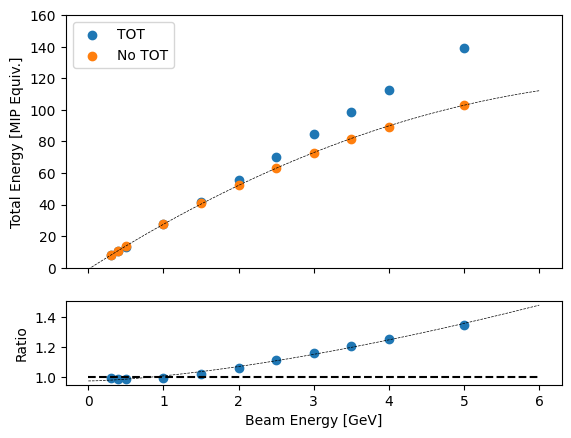

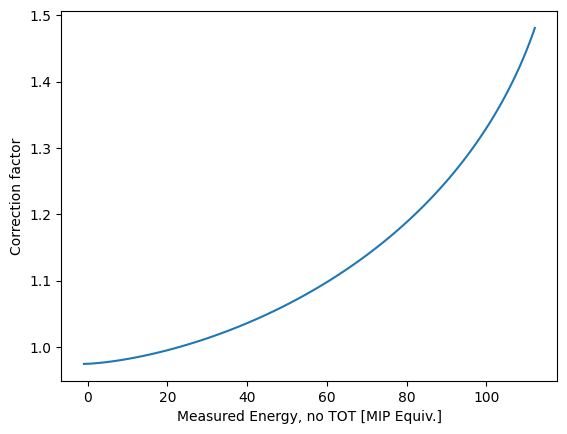

[0.9745721650048653, 0.9750626746956135, 0.9759694194814135, 0.9771497666090386, 0.9785523515517531, 0.9801473711075119, 0.9819146608782813, 0.9838393858890532, 0.9859100316668946, 0.9881173204934401, 0.9904535672106399, 0.9929122686362162, 0.9954878276750943, 0.9981753600814676, 1.0009705544960943, 1.003869568226113, 1.006868947814321, 1.0099655672899819, 1.0131565793374036, 1.0164393760999881, 1.0198115573031792, 1.0232709040264654, 1.0268153568981306, 1.030442997797065, 1.0341520343676367, 1.0379407868145132, 1.0418076765628923, 1.045751216458208, 1.0497700022464125, 1.053862705127276, 1.0580280652128442, 1.0622648857542414, 1.0665720280244628, 1.0709484067642656, 1.0753929861138618, 1.0799047759657043, 1.0844828286839, 1.0891262361441525, 1.0938341270550347, 1.0986056645271005, 1.103440043861089, 1.1083364905304542, 1.1132942583367937, 1.1183126277195625, 1.1233909042038597, 1.1285284169721082, 1.1337245175471844, 1.1389785785760576, 1.144289992704276, 1.1496581715327563, 1.1550825

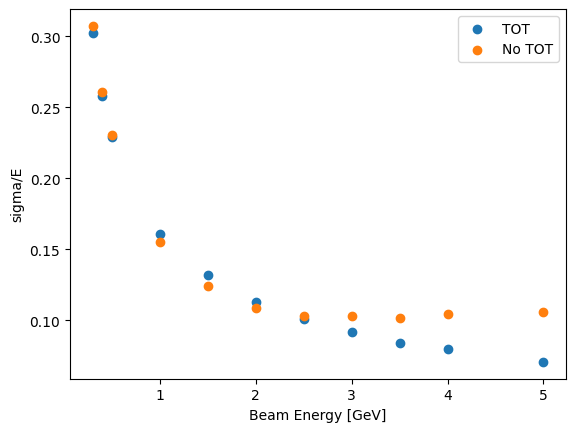

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

#Beam energies (x-axis)
E = [0.3, 0.4, 0.5, 1.0,1.5, 2.0,2.5,3.0,3.5,4.0,5.0]

#With TOT, v8 dataset
sum_tot = [7.84846767, 10.6808201, 13.4295179, 27.47942925,41.65892864, 
           55.84386921,70.17868027,84.44913174,98.57904287,112.47036256,
           139.28110153]

sigma_tot = [2.37392069, 2.75220454, 3.07293196, 4.42317588, 5.48868339, 
             6.30707704, 7.08299352, 7.7645039, 8.25991701,8.93571194,
             9.82773174]

#Without TOT, v9 dataset
sum_notot = [7.90654052, 10.80053302, 13.60968262, 27.63181865, 40.70202585, 
             52.5437338, 63.15792803, 72.86807889, 81.48676377, 89.39562696,
             103.32929034]
sigma_notot = [2.43024008,2.81984649,  3.14022731, 4.28964039, 5.06412354, 
               5.70387369, 6.51126567, 7.48232558, 8.28508613, 9.34915909,
               10.93294616]

fig, axs = plt.subplots(2,1, height_ratios=[1,0.33], sharex=True)
#Energy sum linearity plot
axs[0].scatter(E, sum_tot, label="TOT")
axs[0].scatter(E, sum_notot, label="No TOT")
axs[0].legend()
axs[0].set_ylim(0,160)
axs[0].set_ylabel("Total Energy [MIP Equiv.]")

#Ratio (correction factor)
axs[1].hlines(1.0,0.0,6, linestyle="--",color="black")
axs[1].scatter(E, [sum_tot[i]/sum_notot[i] for i in range(0,len(E))])
axs[1].set_ylabel("Ratio")
axs[1].set_xlabel("Beam Energy [GeV]")

print(min([sum_tot[i]/sum_notot[i] for i in range(0,len(E))]))

#Fit to linearity plot
def f(x, a, b, c):
    return a+b*x+c*x**2

X = np.linspace(0,6,100)
popt_notot, pcov_notot = curve_fit(f, E, sum_notot)

axs[0].plot(X,[f(x,*popt_notot) for x in X], linestyle="--",color="black",linewidth=0.5)

#Power law fit to ratio
def g(x, a, b, c):
    return a+b*x**c

popt_ratio, pcov_ratio = curve_fit(g, E, [sum_tot[i]/sum_notot[i] for i in range(0,len(sum_notot))])
axs[1].plot(X,[g(x,*popt_ratio) for x in X],linestyle="--",color="black",linewidth=0.5)
plt.show()

#Plot correction factor
plt.plot([f(x,*popt_notot) for x in X],[g(x,*popt_ratio) for x in X])
plt.xlabel("Measured Energy, no TOT [MIP Equiv.]")
plt.ylabel("Correction factor")
plt.show()

print([float(g(x,*popt_ratio)) for x in X])

plt.scatter(E, [sigma_tot[i]/sum_tot[i] for i in range(0,len(E))], label="TOT")
plt.scatter(E, [sigma_notot[i]/sum_notot[i] for i in range(0,len(E))], label="No TOT")
plt.legend()
plt.ylabel("sigma/E")
plt.xlabel("Beam Energy [GeV]")
plt.show()

[10.74011008 11.23554624  8.17522558]


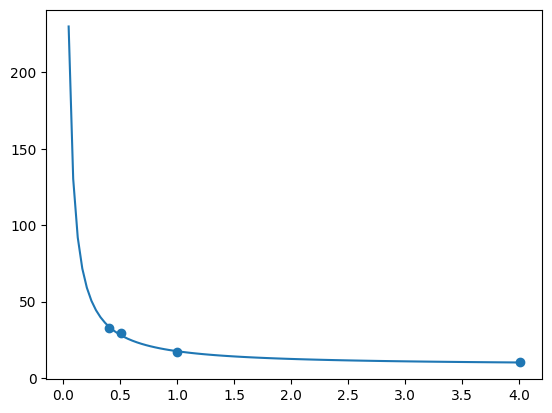

In [4]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

Y = [0.328857672156114, 0.29240380207682204, 0.1697543702794479, 0.1030399692883926]
Y = [k*100 for k in Y]

X = [403.0241841282115, 506.7819362203754, 999.2082163652962, 4002.697368171813]
X = [k/1000 for k in X]

def f(x, a, b, c):
    return np.sqrt((a/np.sqrt(x))**2+(b/x)**2+c**2)

X_gran = np.linspace(0.05,4,100)

popt, pcov = curve_fit(f, X, Y)
plt.plot(X_gran,[f(x,*popt) for x in X_gran])

print(popt)

plt.scatter(X,Y)
plt.show()


[1.58318688e+01 2.58769746e+00 1.31750562e-03]
[11.04850951  6.79565441  8.08369701]
[ 9.37374805 11.80158872  8.6036105 ]


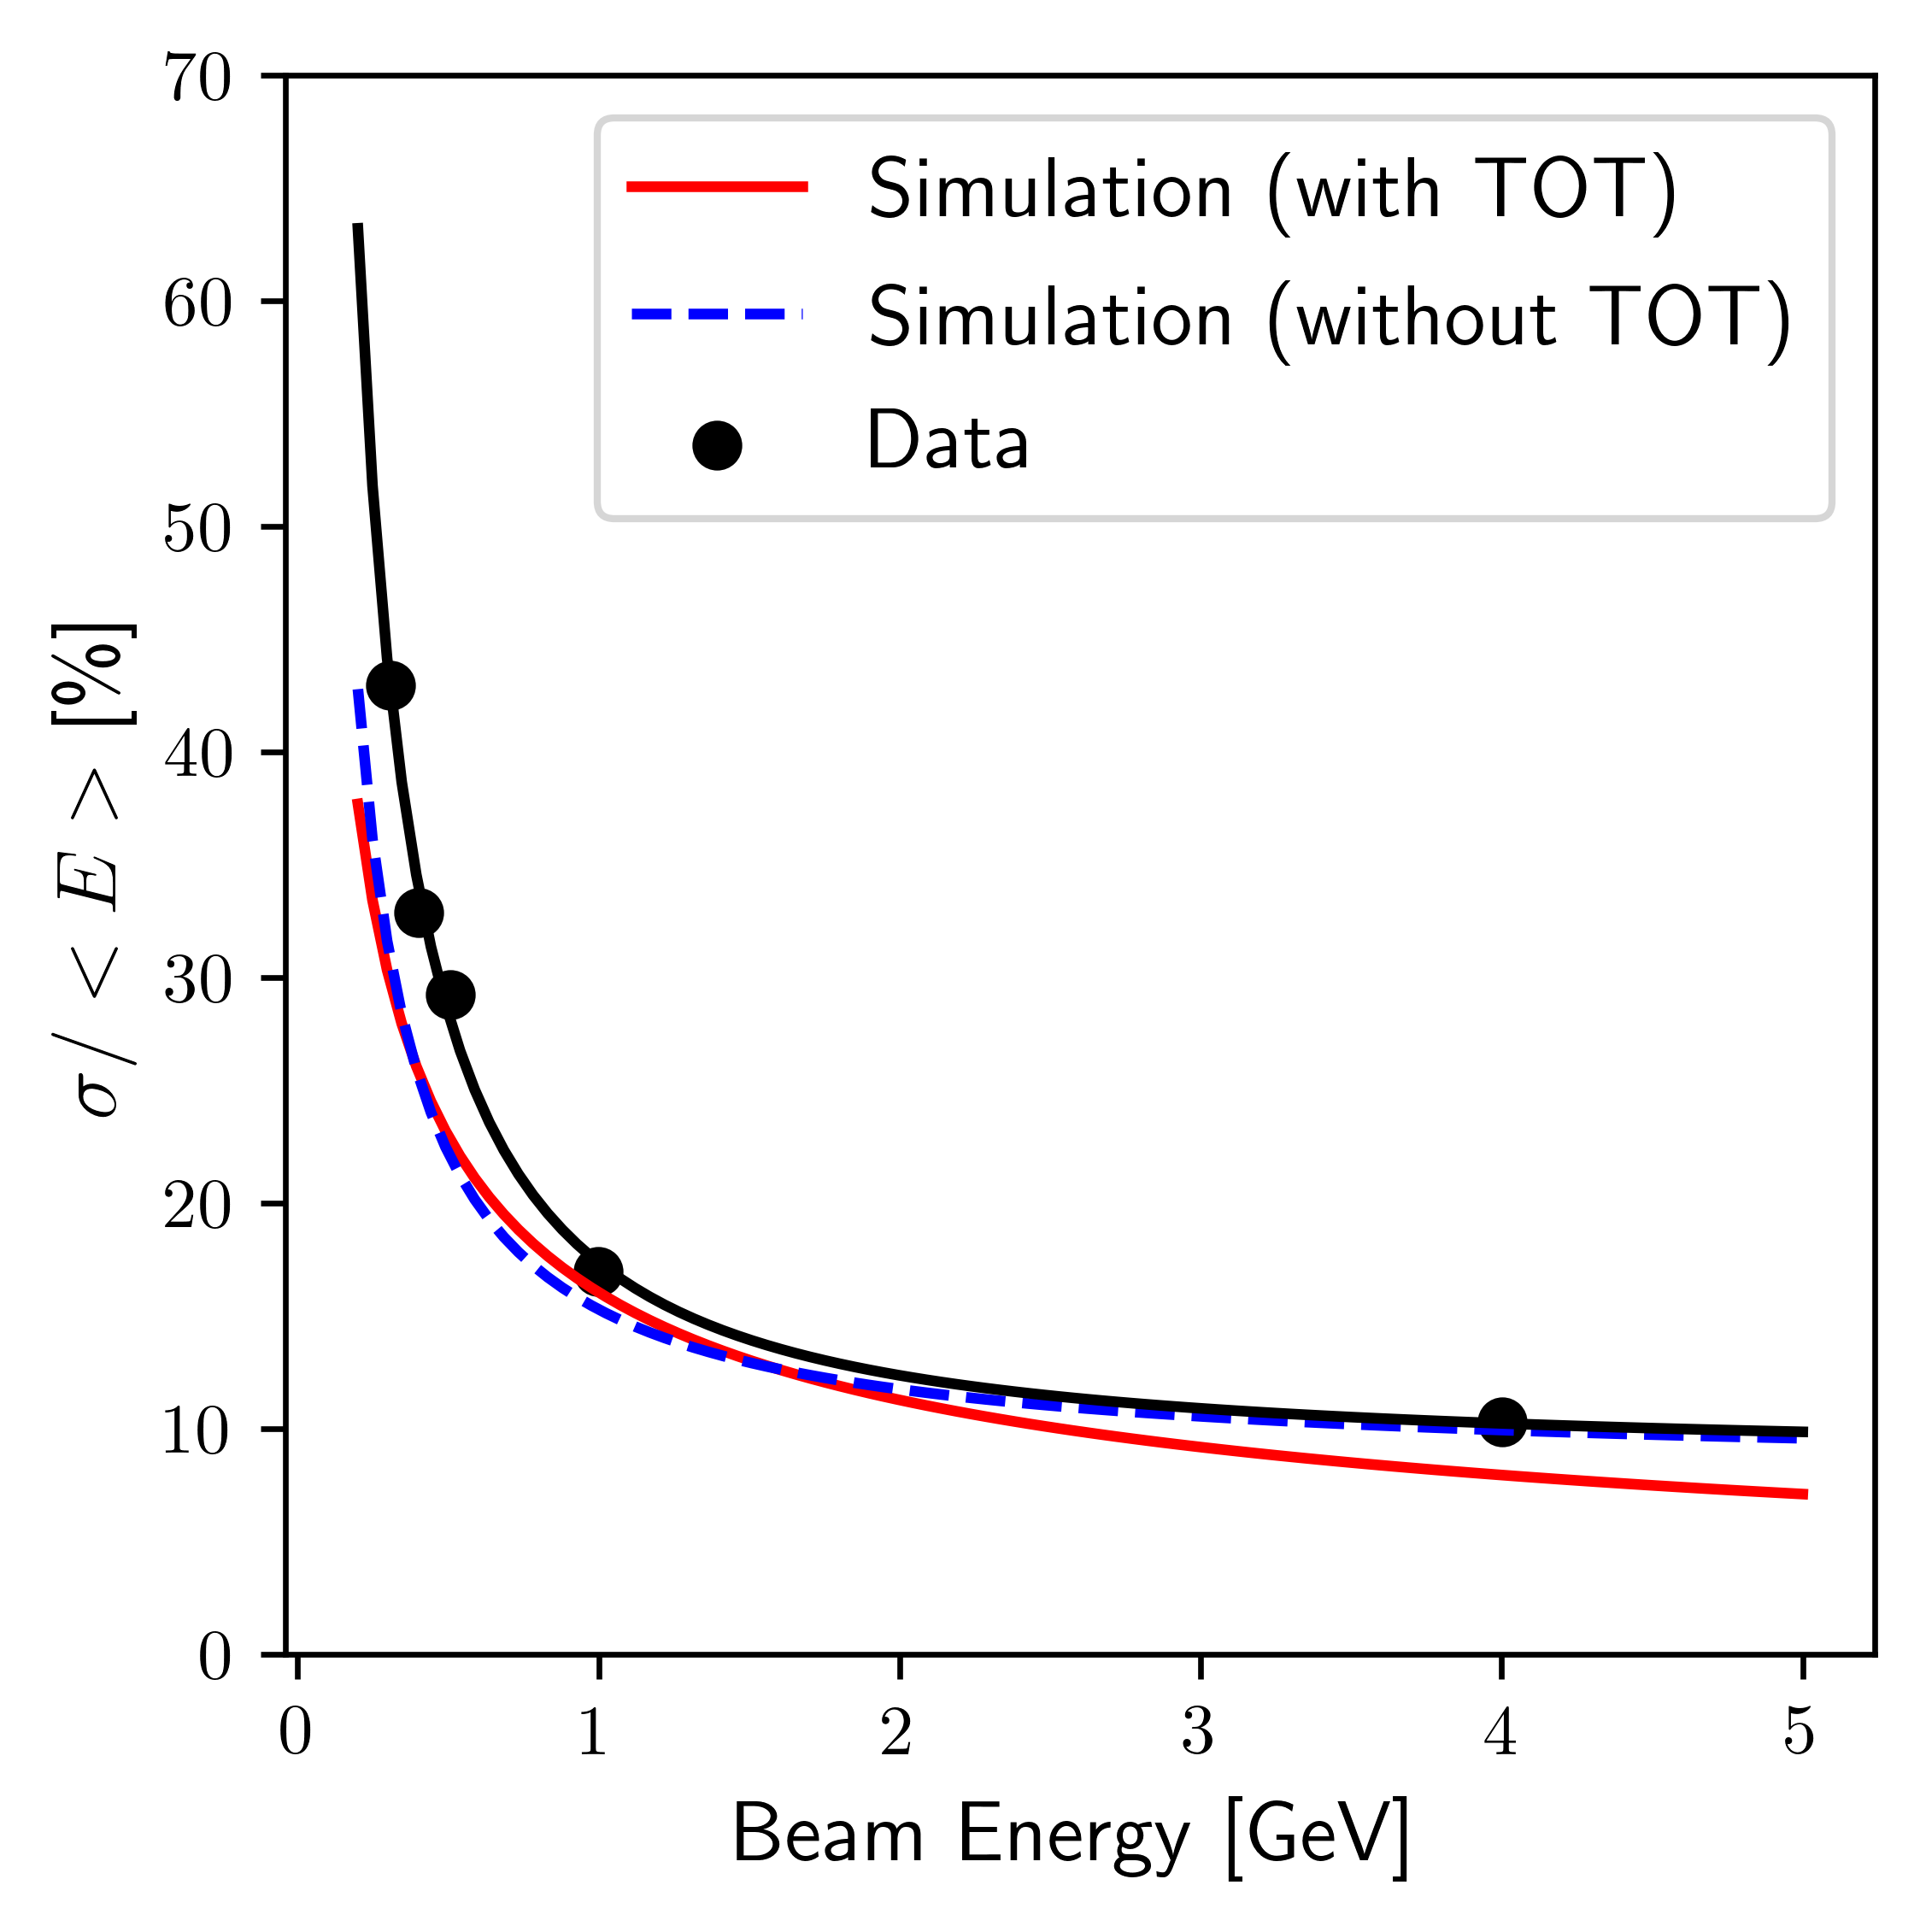

In [34]:


import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

fig = plt.gcf()
fig.set_size_inches(4, 4)

plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 600

E = [0.3, 0.4, 0.5, 1.0,1.5, 2.0,2.5,3.0,3.5,4.0,5.0]

#Y = [0.3016359740012098,0.25823511806668414,0.22988497038072553,0.1610717744919389,0.07988452839624072]
sum_tot = [7.84846767, 10.6808201, 13.4295179, 27.47942925,41.65892864, 
           55.84386921,70.17868027,84.44913174,98.57904287,112.47036256,
           139.28110153]

sigma_tot = [2.37392069, 2.75220454, 3.07293196, 4.42317588, 5.48868339, 
             6.30707704, 7.08299352, 7.7645039, 8.25991701,8.93571194,
             9.82773174]

Y = [sigma_tot[i]/sum_tot[i] for i in range(0,len(E))]
Y = [k*100 for k in Y]

#X = [301.08993374021213,401.1754261677539,501.6549161934281,1002.471324678014,3998.6008034015126]
X = E
X = [k for k in X]

def f(x, a, b, c):
    return np.sqrt((a/np.sqrt(x))**2+(b/(x))**2+c**2)
    #return np.sqrt((a/np.sqrt(x))**2+c**2)

X_gran = np.linspace(0.2,5,100)
#X_gran_inv = np.linspace(1/0.2,1/4,100)

popt, pcov = curve_fit(f, X, Y)
plt.plot([x for x in X_gran],[f(x,*popt) for x in X_gran], label=r"Simulation (with TOT)", color="red")

print(popt)

#plt.scatter([x for x in X],Y, label=r"MC (w/ TOT) $\frac{" +str(round(popt[0],2))+r'\%}{\sqrt{E}}\bigoplus\frac{'+str(round(popt[1]*10,2))
#            +r'MeV}{E}\bigoplus'+str(round(popt[2],2))+r'\%$')




#Y = [0.30742571819321796,  0.2611299901626882,0.22988547550585134,0.15470467228113255,0.10477608434579379]
sum_notot = [7.90654052, 10.80053302, 13.60968262, 27.63181865, 40.70202585, 
             52.5437338, 63.15792803, 72.86807889, 81.48676377, 89.39562696,
             103.32929034]
sigma_notot = [2.43024008,2.81984649,  3.14022731, 4.28964039, 5.06412354, 
               5.70387369, 6.51126567, 7.48232558, 8.28508613, 9.34915909,
               10.93294616]
Y = [sigma_notot[i]/sum_notot[i] for i in range(0,len(E))]
Y = [k*100 for k in Y]


X = E
#X = [308.22230051661666, 404.74160955595744,505.1453308127589,1005.795048005829,3999.2524148138045]
#X = [k/1000 for k in X]

X_gran = np.linspace(0.2,5,100)
#X_gran_inv = np.linspace(1/0.2,1/4,100)

popt, pcov = curve_fit(f, X, Y)
plt.plot(X_gran,[f(x,*popt) for x in X_gran], label=r"Simulation (without TOT)", color="blue",linestyle="--")

print(popt)

#plt.scatter(X,Y, label=r"MC (no TOT) $\frac{" +str(round(popt[0],2))+r'\%}{\sqrt{E}}\bigoplus\frac{'+str(round(popt[1]*10,2))
#            +r'MeV}{E}\bigoplus'+str(round(popt[2],2))+r'\%$')

#plt.scatter(X,Y, label=r"MC (no TOT) $\frac{" +str(round(popt[0],2))+r'\%}{\sqrt{E}}\bigoplus\frac{'+str(round(popt[1]*10,2))
#            +r'MeV}{E}\bigoplus'+str(round(popt[2],2))+r'\%$')


plt.xlabel("Beam Energy [GeV]",fontsize="large")
#plt.xlim(2.25,0)
plt.ylim(0,70)
plt.ylabel(r"$\sigma / <E>$ [\%]", fontsize="large")



Y = [0.42956749923915527, 0.328857672156114, 0.29240380207682204, 0.1697543702794479, 0.1030399692883926]
Y = [k*100 for k in Y]

X = [307.92932794364793, 403.0241841282115, 506.7819362203754, 999.2082163652962, 4002.697368171813]
X = [k/1000 for k in X]

X_gran = np.linspace(0.2,5,100)
#X_gran_inv = np.linspace(1/0.2,1/4,100)

popt, pcov = curve_fit(f, X, Y)
plt.plot([x for x in X_gran],[f(x,*popt) for x in X_gran], color="black")

print(popt)

#plt.scatter([x for x in X],Y, label=r"Data $\frac{" +str(round(popt[0],2))+r'\%}{\sqrt{E}}\bigoplus\frac{'+str(round(popt[1]*10,2))
#            +r'MeV}{E}\bigoplus'+str(round(popt[2],2))+r'\%$')

plt.scatter([x for x in X],Y, label=r"Data", color="black")
plt.legend(fontsize="large")

plt.show()

Text(0.5, 0, 'Beam Energy [GeV]')

<Figure size 2400x3000 with 0 Axes>

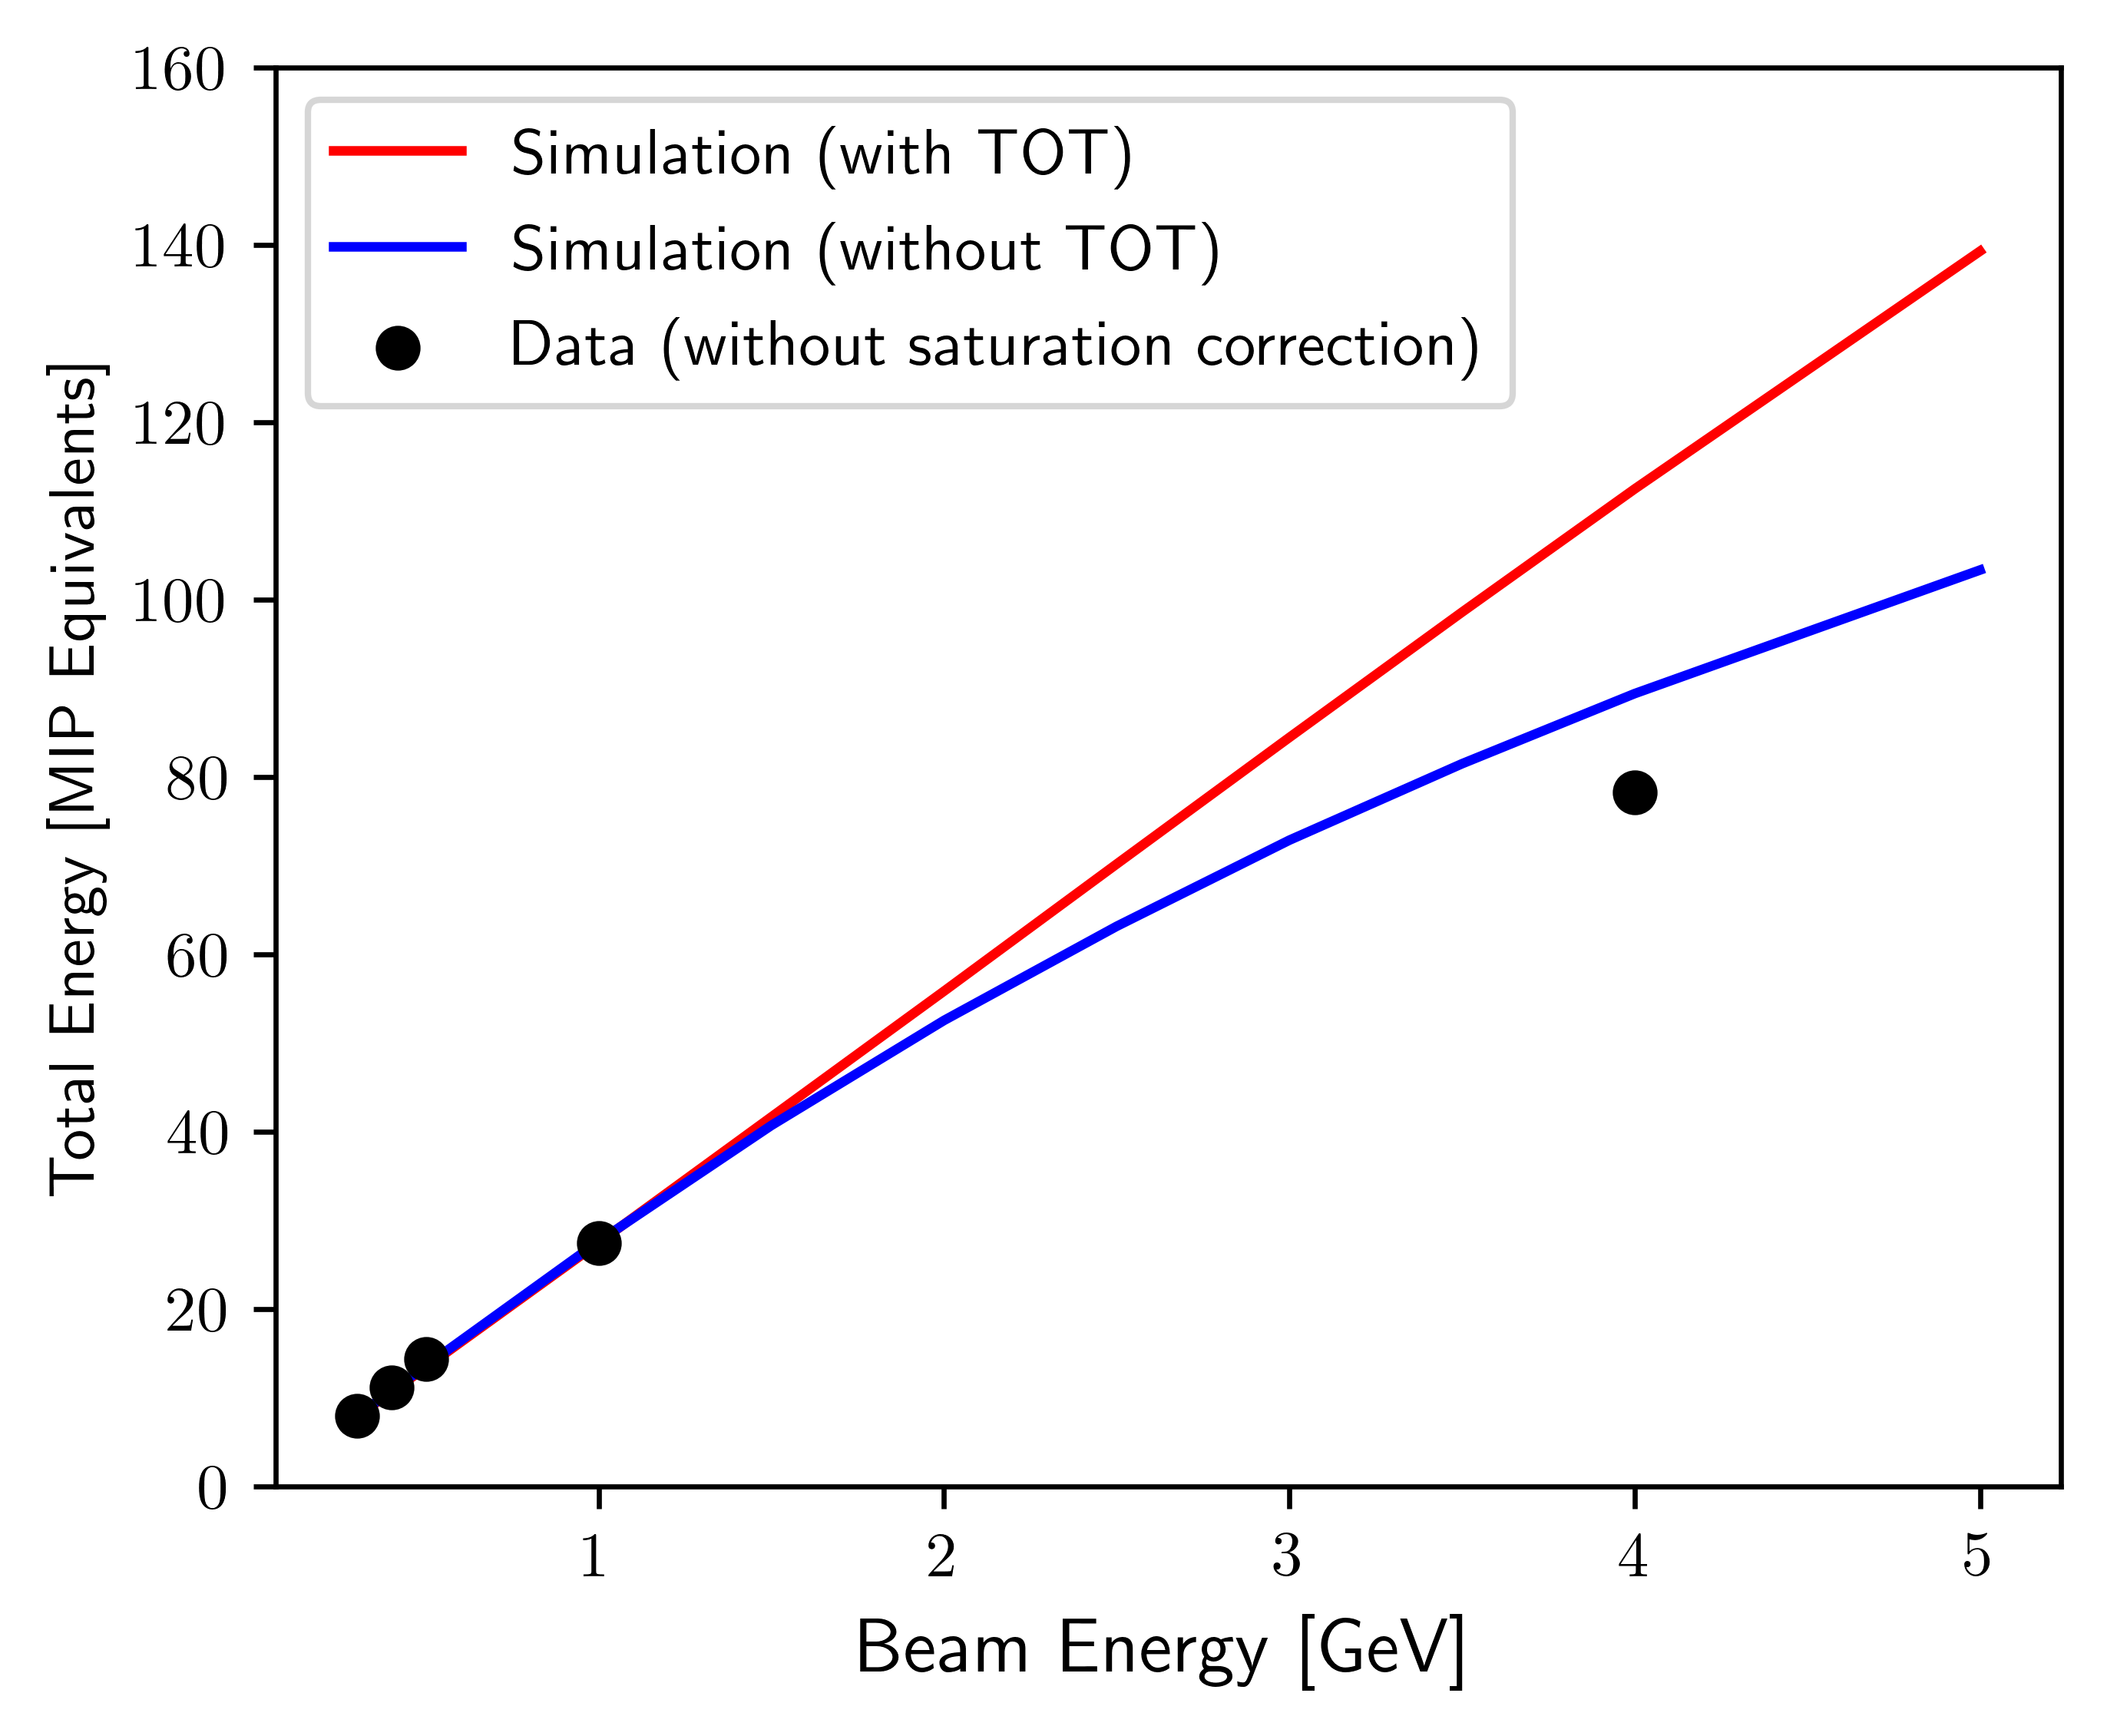

In [31]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

fig = plt.gcf()
fig.set_size_inches(4, 5)

plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 600

#Beam energies (x-axis)
E = [0.3, 0.4, 0.5, 1.0,1.5, 2.0,2.5,3.0,3.5,4.0,5.0]

#With TOT, v8 dataset
sum_tot = [7.84846767, 10.6808201, 13.4295179, 27.47942925,41.65892864, 
           55.84386921,70.17868027,84.44913174,98.57904287,112.47036256,
           139.28110153]

sigma_tot = [2.37392069, 2.75220454, 3.07293196, 4.42317588, 5.48868339, 
             6.30707704, 7.08299352, 7.7645039, 8.25991701,8.93571194,
             9.82773174]

#Without TOT, v9 dataset
sum_notot = [7.90654052, 10.80053302, 13.60968262, 27.63181865, 40.70202585, 
             52.5437338, 63.15792803, 72.86807889, 81.48676377, 89.39562696,
             103.32929034]
sigma_notot = [2.43024008,2.81984649,  3.14022731, 4.28964039, 5.06412354, 
               5.70387369, 6.51126567, 7.48232558, 8.28508613, 9.34915909,
               10.93294616]

E_data = [0.3, 0.4, 0.5, 1.0,4.0]
sum_data = [7.937198289297195, 11.2037978433098, 14.3646098585,  27.436281859070466, 78.26086956521739]

fig, axs = plt.subplots(1,1, figsize=(5,4))
#Energy sum linearity plot
axs.plot(E, sum_tot, label="Simulation (with TOT)", color="red")
axs.plot(E, sum_notot, label="Simulation (without TOT)", color="blue")
axs.scatter(E_data, sum_data, label="Data (without saturation correction)", zorder=10, color="black")
axs.legend()
axs.set_ylim(0,160)
axs.set_ylabel("Total Energy [MIP Equivalents]")
plt.xlabel("Beam Energy [GeV]",fontsize="large")

Text(0, 0.5, 'Total Energy [MIP Equiv.]')

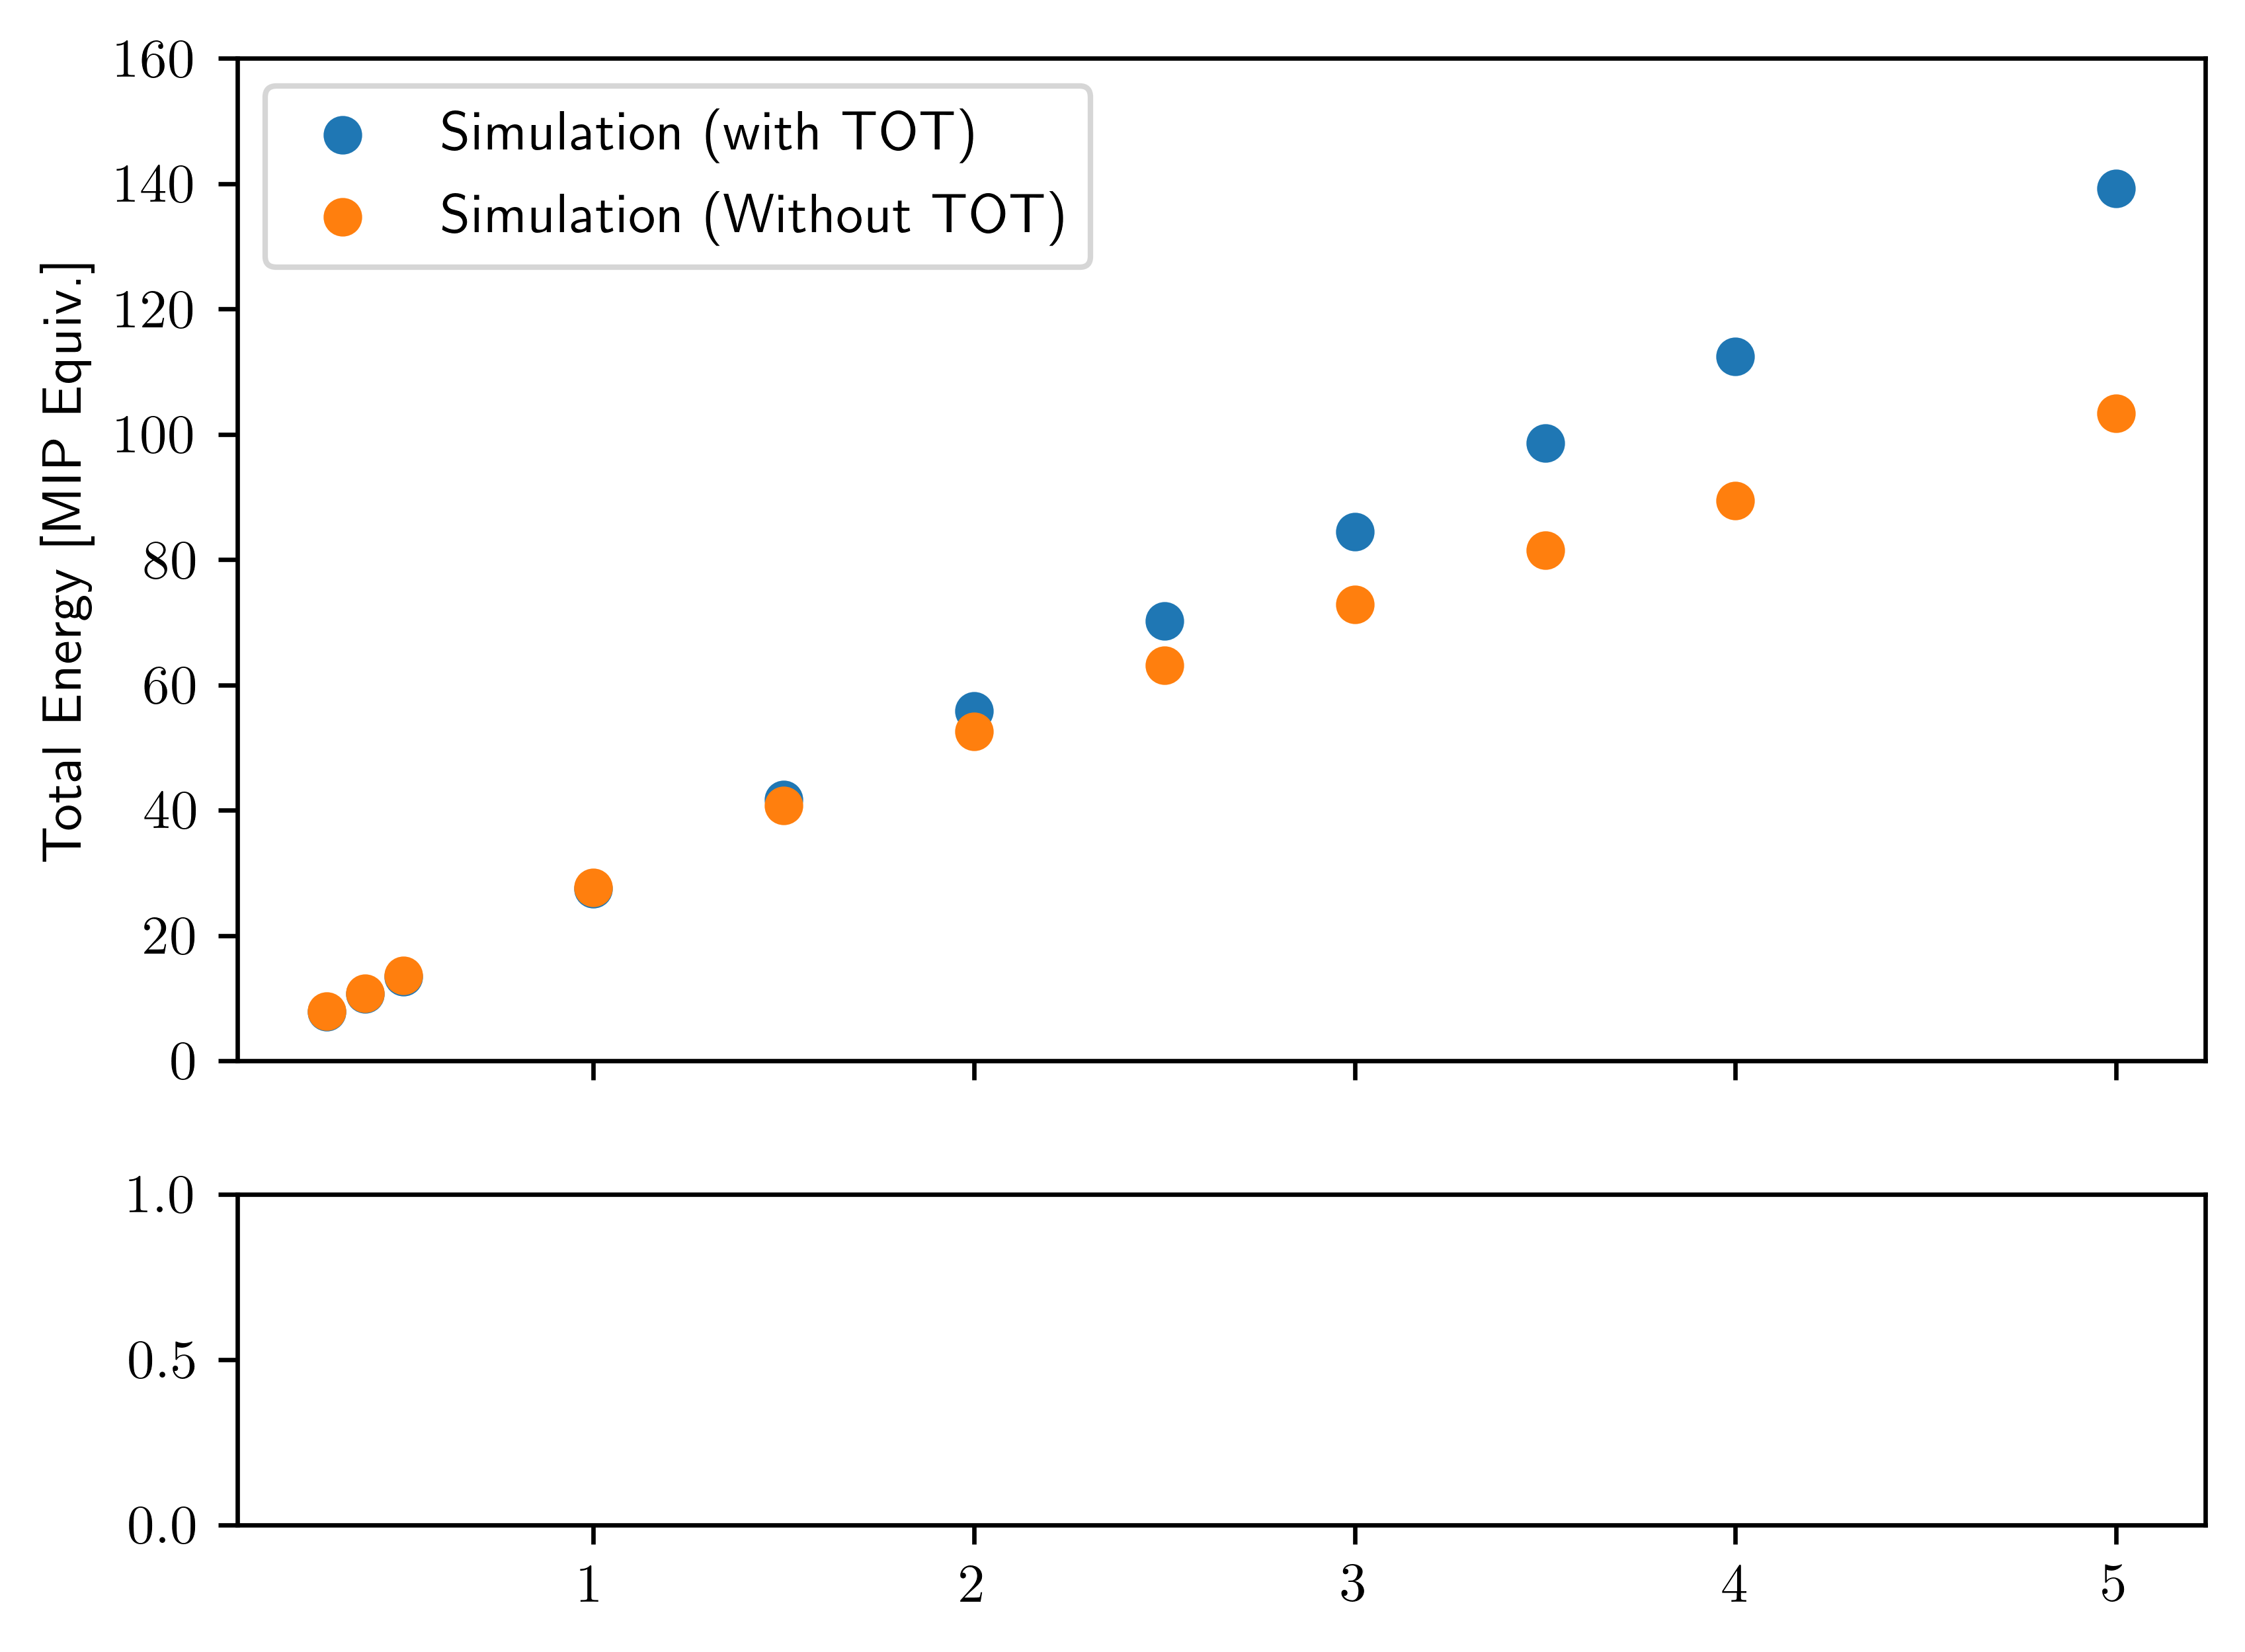